In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import tensorflow as tf
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

tf.get_logger().setLevel("ERROR")

In [4]:
SEED = 123
IMAGE_SIZE = 128
BATCH_SIZE = 16

!rm -rf /content/processed_data
!cp -r "/content/drive/MyDrive/facial_emotion/processed_data" "/content/processed_data"
DATASET_DIR = "/content/processed_data"

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [5]:
import tensorflow as tf
import numpy as np
tf.random.set_seed(SEED)
np.random.seed(SEED)

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int"
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
n_classes = len(class_names)

print("Classes:", class_names)
print("n_classes:", n_classes)

Found 25780 files belonging to 4 classes.
Using 20624 files for training.
Found 25780 files belonging to 4 classes.
Using 5156 files for validation.
Classes: ['angry', 'disgust', 'fear', 'happy']
n_classes: 4


In [6]:
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()
val_batches = temp_batches // 2

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Train batches: 1289
Val batches: 161
Test batches: 162


In [7]:
import os
from collections import Counter

class_counts = {}
total = 0

for i, name in enumerate(class_names):
    path = os.path.join(DATASET_DIR, name)
    count = len([f for f in os.listdir(path) if not f.startswith(".")])
    class_counts[i] = count
    total += count

class_weight = {cls: total/(n_classes*cnt) for cls, cnt in class_counts.items()}
print("Class counts:", class_counts)
print("Class weights:", class_weight)

Class counts: {0: 5920, 1: 5920, 2: 5920, 3: 8020}
Class weights: {0: 1.0886824324324325, 1: 1.0886824324324325, 2: 1.0886824324324325, 3: 0.8036159600997507}


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.08),
], name="aug")

def augment(images, labels):
    return data_augmentation(images, training=True), labels

train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)


In [9]:
train_ds = train_ds.shuffle(128, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

In [10]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    weights="imagenet"
)
base_model.trainable = False  # Frozen phase

# ---- Augmentation INSIDE model  ----
aug_in_model = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.08),
], name="aug_in_model")

# ---- Build model ----
inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

x = aug_in_model(inputs)
x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(n_classes, activation="softmax", dtype="float32")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_in_model (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 4, 4, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,276 (23.84 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [11]:
callbacks_stage2 = [
    ModelCheckpoint(
        "best_frozen.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_stage2,
    class_weight=class_weight,
    verbose=2
)

Epoch 1/10

Epoch 1: val_accuracy improved from -inf to 0.61762, saving model to best_frozen.keras
1289/1289 - 126s - 98ms/step - accuracy: 0.5675 - loss: 1.0117 - val_accuracy: 0.6176 - val_loss: 0.9038 - learning_rate: 1.0000e-03
Epoch 2/10

Epoch 2: val_accuracy improved from 0.61762 to 0.66227, saving model to best_frozen.keras
1289/1289 - 101s - 78ms/step - accuracy: 0.6089 - loss: 0.9334 - val_accuracy: 0.6623 - val_loss: 0.7892 - learning_rate: 1.0000e-03
Epoch 3/10

Epoch 3: val_accuracy improved from 0.66227 to 0.66654, saving model to best_frozen.keras
1289/1289 - 135s - 105ms/step - accuracy: 0.6153 - loss: 0.9169 - val_accuracy: 0.6665 - val_loss: 0.7876 - learning_rate: 1.0000e-03
Epoch 4/10

Epoch 4: val_accuracy did not improve from 0.66654
1289/1289 - 138s - 107ms/step - accuracy: 0.6239 - loss: 0.9032 - val_accuracy: 0.6456 - val_loss: 0.8419 - learning_rate: 1.0000e-03
Epoch 5/10

Epoch 5: val_accuracy improved from 0.66654 to 0.67780, saving model to best_frozen.kera

In [13]:
model = tf.keras.models.load_model("best_frozen.keras")

In [14]:
loss, acc = model.evaluate(test_ds, verbose=2)
print(f"Test Accuracy: {acc*100:.2f}%")

162/162 - 14s - 87ms/step - accuracy: 0.6659 - loss: 0.7973
Test Accuracy: 66.59%


In [15]:
model.save("emotion_frozen.keras")
print("Saved: emotion_frozen.keras")

Saved: emotion_frozen.keras


In [16]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model = tf.keras.models.load_model("best_frozen.keras")

In [17]:
base_model = model.get_layer("efficientnetv2-b0")
base_model.trainable = True


In [18]:
fine_tune_at = int(len(base_model.layers) * 0.70)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Total backbone layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)

Total backbone layers: 270
Fine-tuning from layer: 189


In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
callbacks_stage3 = [
    ModelCheckpoint(
        "best_finetuned.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [21]:
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks_stage3,
    class_weight=class_weight,
    verbose=2
)

Epoch 1/12

Epoch 1: val_accuracy improved from -inf to 0.62422, saving model to best_finetuned.keras
1289/1289 - 152s - 118ms/step - accuracy: 0.5229 - loss: 1.3561 - val_accuracy: 0.6242 - val_loss: 0.9212 - learning_rate: 1.0000e-05
Epoch 2/12

Epoch 2: val_accuracy improved from 0.62422 to 0.64752, saving model to best_finetuned.keras
1289/1289 - 132s - 102ms/step - accuracy: 0.5674 - loss: 1.1630 - val_accuracy: 0.6475 - val_loss: 0.8527 - learning_rate: 1.0000e-05
Epoch 3/12

Epoch 3: val_accuracy improved from 0.64752 to 0.67314, saving model to best_finetuned.keras
1289/1289 - 119s - 92ms/step - accuracy: 0.5907 - loss: 1.0671 - val_accuracy: 0.6731 - val_loss: 0.7877 - learning_rate: 1.0000e-05
Epoch 4/12

Epoch 4: val_accuracy improved from 0.67314 to 0.67624, saving model to best_finetuned.keras
1289/1289 - 121s - 94ms/step - accuracy: 0.6040 - loss: 1.0001 - val_accuracy: 0.6762 - val_loss: 0.7584 - learning_rate: 1.0000e-05
Epoch 5/12

Epoch 5: val_accuracy improved from 0

In [22]:
model = tf.keras.models.load_model("best_finetuned.keras")

In [23]:
print(f"Test Accuracy (Fine-tuned): {acc*100:.2f}%")

Test Accuracy (Fine-tuned): 66.59%


In [24]:
model.save("emotion_model.keras")
print("Saved final model: emotion_model.keras")

Saved final model: emotion_model.keras


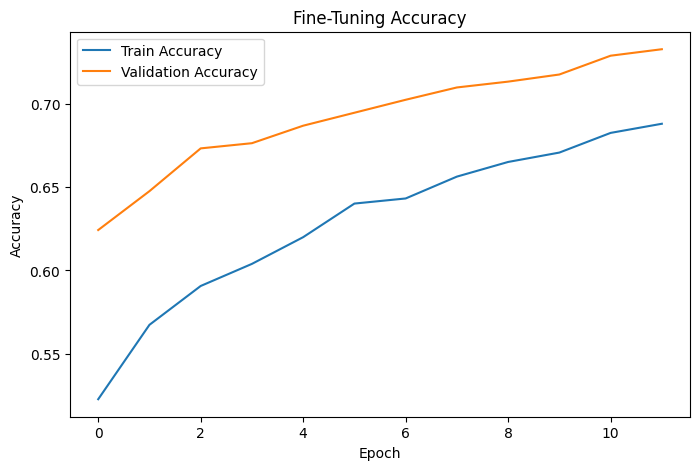

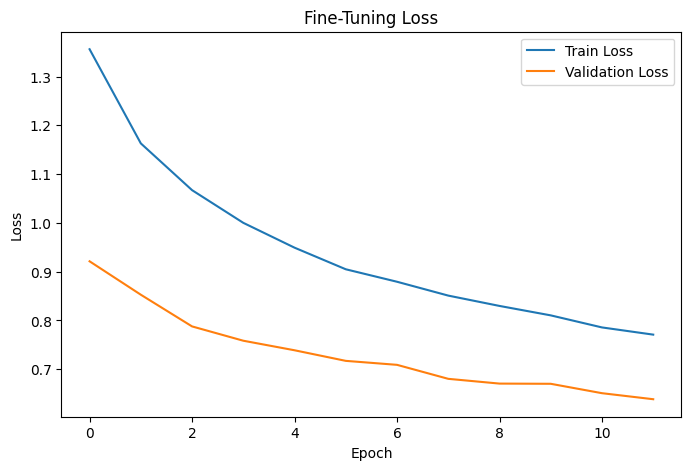

In [25]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history_ft.history['accuracy'], label='Train Accuracy')
plt.plot(history_ft.history['val_accuracy'], label='Validation Accuracy')
plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history_ft.history['loss'], label='Train Loss')
plt.plot(history_ft.history['val_loss'], label='Validation Loss')
plt.title("Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model = tf.keras.models.load_model("emotion_model.keras")

In [28]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

<Figure size 800x600 with 0 Axes>

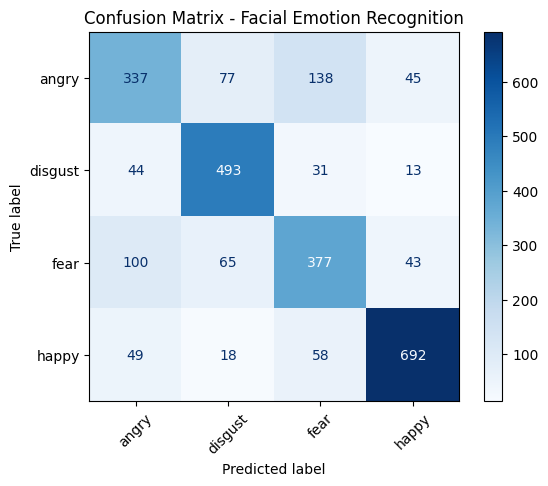

In [29]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(8,6))
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix - Facial Emotion Recognition")
plt.show()

In [34]:
from sklearn.metrics import classification_report, accuracy_score

# Classification Report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

print("Classification Report:\n")
print(report)

print(f"\nOverall Accuracy: {accuracy:.4f}")

Classification Report:

              precision    recall  f1-score   support

       angry     0.6358    0.5645    0.5980       597
     disgust     0.7550    0.8485    0.7990       581
        fear     0.6242    0.6444    0.6341       585
       happy     0.8726    0.8470    0.8596       817

    accuracy                         0.7360      2580
   macro avg     0.7219    0.7261    0.7227      2580
weighted avg     0.7350    0.7360    0.7343      2580


Overall Accuracy: 0.7360
